# **PROJECT 6: LAST-MILE DRONE DELIVERY HUB SYSTEM SIMULATION**

**PROJECT DESCRIPTION**

- A company operating out of a central warehouse in Accra, Ghana uses a fleet of delivery drones to transport packages to customers across Greater Accra.
- Each drone carries one package per trip, has a limited battery that depletes during flight, and must return to the warehouse to recharge after deliveries.
- External factors including package weight and seasonal wind conditions further affect battery consumption rates.
- The company has committed to a Service Level Agreement (SLA) that every package must be delivered within 120 minutes of order placement.
- The core operational question is: **what is the minimum number of drones and charging stations required to meet this commitment reliably?**

This project addresses that question through a Discrete-Event Simulation (DES) built in Python using the SimPy library.

**WHAT WE INTEND TO DO**

- We will build a simulation model that reproduces the full lifecycle of a package delivery: from order arrival at the warehouse, through drone dispatch and flight, to delivery confirmation and drone return.
- The model will incorporate battery drain mechanics, a charging station queue, and stochastic variability in arrivals, distances, and conditions.
- Some **assumptions** we made before starting (geography wise) since climate factors would impact drone speed, etc.:
    - All model parameters are grounded in real-world data↓
    - Drone flight and battery specifications are drawn from the DJI FlyCart 30 manufacturer documentation. **Delivery distance ranges reflect the urban geography of Greater Accra.**
    - Package arrival rates are scaled from published Zipline Ghana operational figures. - Wind conditions follow seasonal meteorological records from **Weather Atlas Accra (2024).**
    - Uncertainty in the model is handled explicitly using two noise components adapted from the **NASA Goebel (2017) prognostic uncertainty framework:** process noise applied to battery drain during flight, and measurement noise applied to the drone's battery sensor reading when making return-to-charge decisions.
- I will run the simulation across a grid of fleet configurations, varying the number of drones from 3 to 10 and the number of charging stations from 1 to 6.
- Each configuration is replicated **30 times using fixed random seeds to ensure statistical reliability.**
- Performance is evaluated primarily by on-time delivery rate, with secondary metrics including mean and 95th-percentile delivery time, drone utilisation, charger utilisation, and queue length over time.
- A seasonal sensitivity analysis will additionally test the recommended configuration across all five Ghanaian climate seasons to verify that performance holds year-round under varying wind conditions.

**The final output is a clear, evidence-based recommendation: the minimum fleet configuration that achieves at least 95% of deliveries within the 120-minute SLA, supported by confidence intervals, sensitivity results, and a cost-efficiency analysis.**


**TECH STACK (TOOLS AND LIBRARIES)**

- SimPy — Discrete-Event Simulation engine
- NumPy — Random sampling and numerical operations
- Pandas — Results logging and aggregation
- Matplotlib / Seaborn — Static charts and visualisations
- Plotly — Interactive visualisations
- SciPy — Statistical analysis and confidence interval computation
- Google Colab — Development and execution environment
- Google Drive — Shared data and output storage

**DELIVERABLES**

1. Simulation model (Python, single notebook).
2. Model description and assumptions document.
3. Experiment plan and scenario run results.
4. Results summary with tables and figures.
5. Final recommendation with supporting evidence.

### **TABLE OF CONTENTS**
1. Setup and Imports
2. Model Parameters and Configuration
3. Helper Functions
4. Drone Class
5. SimPy Processes
6. Single Run Test
7. Noise Verification
8. Experiment Grid
9. Summary Statistics
10. Seasonal Sensitivity Analysis
11. Visualisations
12. Results Interpretation
13. Final Recommendation
14. References

### **SETUP AND IMPORTS**

In [95]:
# if sharing notebooks or for collaboration
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/DroneSimAccra')

# Install dependencies (only needed once per session)
!pip install simpy tqdm fpdf2 -q

# Shared path shortcut — use this everywhere
DRIVE_PATH = '/content/drive/MyDrive/DroneSimAccra'
DATA_PATH  = f'{DRIVE_PATH}/data/'
FIG_PATH   = f'{DRIVE_PATH}/figures/'

# import config # all shared parameters
# from simulation import run_simulation

print("Drive mounted, paths set. Ready :)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted, paths set. Ready :)


In [96]:
# install dependencies
!pip install simpy tqdm fpdf2 -q

# standard imports
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats
from tqdm.notebook import tqdm
import os, warnings
warnings.filterwarnings('ignore')

# Output folders
os.makedirs('data', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print('Setup complete :)')

Setup complete :)


### **DES SIMULATION MODEL BREAKDOWN**
Before we get into it, this project is a discrete-event simulation (DES) model, which is a system as a sequence of events that occur at specific points in time.
Meaning that between events, nothing changes so the system sort of jumps from one event to the next.

Here, time is not continuous. Everything happens in discrete, countable moments:
- A package arrives (event)
- A drone departs (event)
- A battery hits 25% (event)
- A drone begins charging (event)
- A package is delivered (event)

This simulation is stochastic meaning inputs are random variables:
- Arrival times follow a Poisson process.
- Delivery distances are Uniformly distributed.
- Package weight (heavy/normal) is Bernoulli.
- Battery drain has Gaussian noise.

So because of this, we would need about 30 replications.

### **ALL PARAMETERS (fixed inputs)**
#### *Assumptions and justifications*
Most of these parameters below are cited, not assumed, thus referencing our three primary sources: DJI FlyCart 30, Weather Atlas Accra, Zipline Ghana.

##### **MODEL PARAMS**
1. **DRONE_SPEED= 54 km/h (15 m/s).** DJI FlyCart 30 cruise speed in standard conditions. This is a manufacturer specification used to calculate flight duration from distance.
2. **BATTERY_DRAIN_BASE= 5% per km**
Derived: 100% ÷ midpoint of [16km full load, 28km empty] = 100 ÷ 20 = 5%/km. A middle-ground assumption.
3. **HEAVY_PACKAGE_MULT= ×1.5 drain** DJI spec: full load (30kg) gives 16km range vs 28km empty = 1.75× difference. Using ×1.5 is conservative. 30% of packages classified heavy.
4. **BATTERY_RTH_THRESHOLD= 25%** Project default RTH (Return-to-Home) low battery trigger. Provides safety buffer against measurement noise and unexpected drain.
5. **RECHARGE_TIME= 26.5 min** DJI FlyCart 30 official spec. Proportional charging: if drone arrives at 25% battery, charges for (75/100) × 26.5 = ~20 min.
6. **ARRIVAL_RATE λ(t)= Poisson, time-varying.**
λ=2/hr (7-9am), λ=8/hr (9am-12pm), λ=5/hr (12-3pm), λ=9/hr (3-7pm), λ=3/hr (7-10pm). Reflects real e-commerce demand shape.
7. **DELIVERY_DISTANCE= Uniform(3, 16) km.** Based on Accra urban geography. Simplified as uniform for tractability.
8. **SIM_DURATION= 900 min (15 hours)** Operating hours: 7am to 10pm. Ghana daytime operations (ops). Nighttime drone ops face regulatory and visibility constraints.

##### **STATE VARIABLES**
1. **drone.battery = 0 – 100%** True battery level. Drained per km flown, restored during charging. The core state variable the entire simulation revolves around.
2. **drone.status = idle / flying / charging / waiting** Drives availability logic. A drone is only available to dispatch when status = idle. All other states remove it from the active pool.
3. **package.wait_time = 0 - unbounded (min)** Time package spends in queue before a drone picks it up. Primary cause of SLA violations when fleet is undersized.
4. **queue.length = 0 - N (integer)** Real-time count of packages awaiting a drone. Key signal for system overload. Logged every 10 simulated minutes for time-series plots.

##### **NOISE PARAMETERS**
1. **PROCESS_NOISE = N(0, 0.5%) per km.** Motor efficiency variance, altitude micro-changes, turning. Applied per-km during flight. Borrowed from NASA Goebel 2017 prognostic uncertainty framework.
2. **MEASUREMENT_NOISE= N(0, 1.5%)** Battery sensor accuracy. Drone's reported battery ≠ true battery. Causes occasional premature returns (underestimates) or risky flights (overestimates).

In [97]:
'''All constants defined here in one place. Grouped into blocks:
- Drone specs (speed, drain rates, RTH threshold, recharge time)
- Package parameters (heavy probability, distance range)
- Time-varying arrival rates by hour
- Wind seasonal multipliers by month
- Noise parameters
- Simulation settings (duration, SLA limit, replications)

Nothing hardcoded anywhere else in the notebook :)
'''
# DRONE SPECS
DRONE_SPEED = 54.0 # km/h cruise speed (15 m/s)
DRAIN_BASE = 5.0 # % battery per km for loaded flight
DRAIN_RETURN = 3.57 # % battery per km
HEAVY_MULT = 1.5 # drain multiplier for heavy packages
RTH_THRESHOLD = 25.0 # % return-to-home trigger
RECHARGE_FULL_MIN = 26.5 # minutes till full 0% to 100% charge
BATTERY_EMERGENCY  = 5.0   # % if battery drops below this mid-flight, drone makes emergency landing, package fails
MAX_QUEUE_WAIT  = 90.0  # minutes. if a package waits longer than this before getting a drone, mark it as failed (90 min leaves no time for even a short flight)

# PACKAGE PARAMETERS
HEAVY_PROB = 0.30  # Bernoulli(p=0.30) — 30% of packages classified heavy
DIST_MIN = 3.0 # km — minimum delivery distance (inner Accra)
DIST_MAX = 8.0 # km — maximum delivery distance (outer Accra/Tema)
# NOTE: actual distance sampled per delivery via np.random.uniform(DIST_MIN, DIST_MAX)

# TIME-VARYING ARRIVAL RATE λ (packages/hour)
# Simulation starts at SIM_START_HOUR.
LAMBDA_BY_HOUR = {
    7:  2.0,   # 7am–9am   : low morning
    8:  2.0,
    9:  8.0,   # 9am–12pm  : morning peak
    10: 8.0,
    11: 8.0,
    12: 5.0,   # 12pm–3pm  : mid-day
    13: 5.0,
    14: 5.0,
    15: 9.0,   # 3pm–7pm   : afternoon peak
    16: 9.0,
    17: 9.0,
    18: 9.0,
    19: 3.0,   # 7pm–10pm  : evening wind-down
    20: 3.0,
    21: 3.0,
}
# note: interarrival time sampled per package via np.random.exponential(60 / lambda)

# WIND SEASONAL MULTIPLIERS
# Multiplier (mult) = season_wind_speed / 11.6 km/h (Harmattan baseline)
# Applied multiplicatively to DRAIN_BASE during flight
WIND_SEASONS = {
    'harmattan' : {'months': [11, 12, 1, 2], 'mult': 1.00},  # 11.6 km/h
    'pre_rains' : {'months': [3, 4],         'mult': 1.15},  # 14.0 km/h
    'main_rains': {'months': [5, 6],         'mult': 1.25},  # 15.5 km/h
    'mid_dry'   : {'months': [7, 8, 9],      'mult': 1.25},  # 16.1 km/h
    'post_rains': {'months': [10],           'mult': 1.10},  # 13.0 km/h
}

# NOISE PARAMETERS
# These are standard deviations only. Actual noise is sampled per event, not here.
PROCESS_NOISE_SD  = 0.5 # % per km for motor efficiency variance (process noise) | this will push a drone to RTH earlier than expected or allow it to fly slightly longer than safe

MEASURE_NOISE_SD  = 0.8 # % of battery sensor inaccuracy (measurement noise)

# note: sampled inside drain_battery() and read_battery() respectively

# SIMULATION SETTINGS
SIM_START_HOUR = 7  # operating day begins at 7am
SIM_DURATION   = 900 # minutes of 15 hours (7am to 10pm)
SLA_LIMIT      = 120 # minutes of 2-hour delivery promise
REPLICATIONS   = 30 # runs per configuration (for Confidence Interval -95%- estimation)

# cross checking variables
print("Parameters loaded :)")
print(f"- Drone speed         : {DRONE_SPEED} km/h")
print(f"- Base drain (loaded) : {DRAIN_BASE}% per km")
print(f"- Base drain (return) : {DRAIN_RETURN}% per km")
print(f"- RTH threshold       : {RTH_THRESHOLD}%")
print(f"- Recharge (full)     : {RECHARGE_FULL_MIN} min")
print(f"- Distance range      : {DIST_MIN}–{DIST_MAX} km")
print(f"- Heavy package prob  : {HEAVY_PROB:.0%}")
print(f"- SLA limit           : {SLA_LIMIT} min")
print(f"- Sim duration        : {SIM_DURATION} min ({SIM_DURATION//60} hrs)")
print(f"- Replications        : {REPLICATIONS}")
print(f"- Process noise SD    : {PROCESS_NOISE_SD}% per km")
print(f"- Measurement noise SD: {MEASURE_NOISE_SD}%")

Parameters loaded :)
- Drone speed         : 54.0 km/h
- Base drain (loaded) : 5.0% per km
- Base drain (return) : 3.57% per km
- RTH threshold       : 25.0%
- Recharge (full)     : 26.5 min
- Distance range      : 3.0–8.0 km
- Heavy package prob  : 30%
- SLA limit           : 120 min
- Sim duration        : 900 min (15 hrs)
- Replications        : 30
- Process noise SD    : 0.5% per km
- Measurement noise SD: 0.8%


### **HELPER FUNCTIONS**
Two helper functions used throughout the simulation.
- `get_wind_mult(month)`: returns seasonal battery multiplier for a given calendar month
- `get_lambda(sim_minutes)`: returns arrival rate for current simulation time.

In [98]:
def get_wind_mult(month):
    # returns the battery drain multiplier for a given calendar month
    # looks up which season the month belongs to and returns that season's multiplier
    # defaults to 1.0 (no wind effect) if month is not found
    for season in WIND_SEASONS.values():
        if month in season['months']:
            return season['mult']
    return 1.0


def get_lambda(sim_minutes):
    # returns the package arrival rate (packages/hour) for the current simulation time
    # converts simulation minutes to a clock hour, then looks up the rate from LAMBDA_BY_HOUR
    # caps at hour 21 (9pm) as it's the last defined hour before operations close at 10pm
    current_hour = SIM_START_HOUR + int(sim_minutes // 60)
    current_hour = min(current_hour, 21)
    return LAMBDA_BY_HOUR.get(current_hour, 3.0)


# quick checks
print(f"January wind multiplier: {get_wind_mult(1)}")
print(f"June wind multiplier: {get_wind_mult(6)}")
print(f"Lambda at t=0 (7am): {get_lambda(0)} packages/hr")
print(f"Lambda at t=180 (10am): {get_lambda(180)} packages/hr")
print(f"Lambda at t=480 (3pm): {get_lambda(480)} packages/hr")

January wind multiplier: 1.0
June wind multiplier: 1.25
Lambda at t=0 (7am): 2.0 packages/hr
Lambda at t=180 (10am): 8.0 packages/hr
Lambda at t=480 (3pm): 9.0 packages/hr


### **DRONE CLASS**
- The Drone class represents a single delivery drone operating within the simulation.
- Each drone object maintains its own state independently, meaning the simulation tracks every drone in the fleet individually throughout the run.

**State Variables:**
*   battery: the drone's true battery level, expressed as a percentage from 0 to 100. This is the ground truth value that the simulation tracks internally.
*   status: the drone's current activity. Takes one of four values — idle, flying, charging, or waiting_for_charger

**Utilisation Counters (these accumulate time spent in each active state, used later to compute utilisation rates across the fleet):**
*   time_flying : total minutes spent in flight (outbound and return)
*   time_charging : total minutes spent actively charging at a station
*   time_waiting : total minutes spent queuing for a charging station to become available.

**Noise Application**
- Noise is not applied globally but at the point of each relevant event.
- Process noise is sampled fresh inside drain_battery() on every kilometre flown.
- Measurement noise is sampled fresh inside read_battery() every time the drone checks its battery to make a return-to-charge decision.
- This means no two flights or readings are identical, even under the same conditions.

In [99]:
# drone class
'''Full Drone class:
- `__init__`
- `drain_battery` with process noise
- `read_battery` with measurement noise
- `charge` as a SimPy generator process'''

class Drone:
    def __init__(self, env, drone_id, chargers):
        # simpy environment reference and unique drone identifier
        self.env = env
        self.id = drone_id
        self.chargers = chargers

        # state variables, remember these change throughout the simulation
        self.battery = 100.0 # true battery level (%)
        self.status = 'idle' # current activity

        # utilisation counters accumulate minutes in each state
        self.time_flying = 0.0
        self.time_charging = 0.0
        self.time_waiting = 0.0

    def drain_battery(self, km, is_heavy, wind_mult, is_return=False):
        # drains battery based on distance flown, package weight, and wind conditions
        # process noise(added error) sampled fresh every call so that no two flights are identical
        base = DRAIN_RETURN if is_return else DRAIN_BASE
        mult = HEAVY_MULT if is_heavy else 1.0

        #scaling noise per km
        noise = np.random.normal(0, PROCESS_NOISE_SD * np.sqrt(km))  # process noise
        drain = (base * mult * wind_mult) * km + noise
        self.battery = max(0.0, self.battery - drain)

    def read_battery(self):
        # returns the drone's reported battery level, not the true value
        # measurement noise is added to simulate sensor inaccuracy
        # the drone makes all return-to-charge decisions using this reported value
        noise = np.random.normal(0, MEASURE_NOISE_SD) # measurement noise
        return max(0.0, min(100.0, self.battery + noise))

    def charge(self):
        # simpy generator process requests a charging station and waits if none available
        # once a station is acquired, charges proportionally based on battery deficit
        self.status = 'waiting_for_charger'
        wait_start  = self.env.now

        with self.chargers.request() as req:
            yield req  # event: charger acquired
            self.time_waiting += self.env.now - wait_start
            self.status      = 'charging'
            charge_start     = self.env.now
            deficit          = (100.0 - self.battery) / 100.0
            charge_time      = deficit * RECHARGE_FULL_MIN

            yield self.env.timeout(charge_time)  # for event: charge complete
            self.time_charging += self.env.now - charge_start
            self.battery = 100.0


# quick check to confirm drone initialises correctly
_env = simpy.Environment()
_chargers = simpy.Resource(_env, capacity=2)
_d = Drone(_env, drone_id=0, chargers=_chargers)

print(f"drone id: {_d.id}")
print(f"battery: {_d.battery}%")
print(f"status: {_d.status}")
print(f"time_flying: {_d.time_flying}")
print(f"time_charging: {_d.time_charging}")
print(f"time_waiting: {_d.time_waiting}")

drone id: 0
battery: 100.0%
status: idle
time_flying: 0.0
time_charging: 0.0
time_waiting: 0.0


### **SimPy PROCESSES**
Describing the event chain: package arrives, drone acquired, fly out, deliver, fly back, battery check, charge if needed, drone returns to pool.

In [100]:
# deliver_package process
# Full SimPy generator for a single package lifecycle. Logs all results to the results list. Logs queue depth to q_log at moment of arrival.

def deliver_package(env, pkg_id, drone_pool, chargers, results, wind_mult, q_log):
    # records arrival time and samples package properties
    arrival  = env.now
    distance = np.random.uniform(DIST_MIN, DIST_MAX)
    is_heavy = np.random.random() < HEAVY_PROB
    fly_time = (distance / DRONE_SPEED) * 60   # convert km/h to minutes

    # log queue depth at the moment this package arrives
    q_log.append({'time': arrival, 'q_len': len(drone_pool.items)})

    # then we wait for an available drone so our queue builds here when fleet is undersized
    drone = yield drone_pool.get()  # event: drone acquired
    drone.status = 'flying'
    wait_time    = env.now - arrival

    # outbound flight to customer
    yield env.timeout(fly_time)  # event: arrived at destination
    drone.drain_battery(distance, is_heavy, wind_mult, is_return=False)
    drone.time_flying += fly_time

    # log delivery result
    delivery_time = env.now - arrival
    results.append({
        'pkg_id' : pkg_id,
        'arrival_t' : arrival,
        'delivery_t' : delivery_time,
        'wait_t' : wait_time,
        'flight_t' : fly_time,
        'distance_km' : round(distance, 2),
        'is_heavy' : is_heavy,
        'late' : delivery_time > SLA_LIMIT,
        'drone_id' : drone.id,
        'wind_mult' : wind_mult,
    })

    # return flight is empty so lower drain rate of the battery
    yield env.timeout(fly_time) # event: back at warehouse
    drone.drain_battery(distance, False, wind_mult, is_return=True)
    drone.time_flying += fly_time

    # battery decision uses reported (noisy) reading, not true battery
    if drone.read_battery() < RTH_THRESHOLD:
        yield env.process(drone.charge()) # event: charge cycle begins

    # return drone to the pool for the next package
    drone.status = 'idle'
    yield drone_pool.put(drone) # event: drone available again

In [101]:
def package_generator(env, drone_pool, chargers, results, wind_mult, q_log):
    # continuously generates packages for the duration of the simulation
    # interarrival time drawn from exponential distribution using poisson arrivals
    pkg_id = 0
    while True:
        lam = get_lambda(env.now)
        interarrival = np.random.exponential(60.0 / lam)  #interarrival times = minutes between arrivals
        yield env.timeout(interarrival) # event: package arrives
        env.process(deliver_package(env, pkg_id, drone_pool, chargers, results, wind_mult, q_log))
        pkg_id += 1

In [102]:
# run_simulation Function
'''Main entry point. Takes n_drones, n_chargers, seed, month as arguments. Initialises SimPy environment, creates drone pool and charger resource, runs simulation, returns results list, q_log, and drones list.'''

def run_simulation(n_drones, n_chargers, seed, month=1):
    # seeds numpy for reproducibility as the same seed gives identical results every run
    np.random.seed(seed)

    # initialising simpy environment and shared resources
    env = simpy.Environment()
    chargers = simpy.Resource(env, capacity=n_chargers)
    drone_pool = simpy.FilterStore(env)
    results = []
    q_log = []
    wind_mult = get_wind_mult(month)

    # create drone fleet where all our drones start idle at 100% battery
    drones = [Drone(env, i, chargers) for i in range(n_drones)]
    for drone in drones:
        drone_pool.put(drone)

    # start the package generator process
    env.process(package_generator(env, drone_pool, chargers, results, wind_mult, q_log))

    # run until end of operating day
    env.run(until=SIM_DURATION)

    return results, q_log, drones

print('the run_simulation() function is ready.')

the run_simulation() function is ready.


### **SINGLE RUN TEST**
Before running the full experiment grid, we verify the simulation produces sensible outputs on a single test run: 5 drones, 2 chargers, seed 1, January.

In [103]:
# Single Run Test
# this run will:
'''
- Run with 5 drones, 2 chargers, seed 1, month 1 (so January which is necessary for weather conditions and reporting).
- Convert results to DataFrame.
- Print total packages, on-time rate, mean delivery time, P95 delivery time, late count.
- Finally, display first 5 rows.'''

results, q_log, drones = run_simulation(n_drones=5, n_chargers=2, seed=1, month=1)
df = pd.DataFrame(results)

print(f'total packages delivered : {len(df)}')
print(f'on-time rate : {(~df["late"]).mean():.1%}')
print(f'mean delivery time : {df["delivery_t"].mean():.1f} min')
print(f'p95 delivery time : {df["delivery_t"].quantile(0.95):.1f} min')
print(f'late deliveries : {df["late"].sum()}')
print()
df.head()

total packages delivered : 81
on-time rate : 100.0%
mean delivery time : 7.1 min
p95 delivery time : 13.9 min
late deliveries : 0



,pkg_id,arrival_t,delivery_t,wait_t,flight_t,distance_km,is_heavy,late,drone_id,wind_mult
0,0,16.188175,3.333969,0.0,3.333969,3.00,False,False,0,1.0
1,1,54.411933,7.140108,0.0,7.140108,6.43,True,False,1,1.0
2,2,70.712114,4.113261,0.0,4.113261,3.70,True,False,2,1.0
3,3,95.252333,6.295363,0.0,6.295363,5.67,False,False,3,1.0
4,4,190.276100,3.434935,0.0,3.434935,3.09,False,False,4,1.0


In [104]:
# Drone Utilisation Check
# this shows how each drone spent its time across the simulation run

''' Here, we will print a table showing time_flying, time_charging, time_waiting as a percentage of total sim duration for each drone in the test run.'''

print(f"{'drone':>6} {'flying':>10} {'charging':>10} {'waiting':>10} {'idle':>10}")
print('-' * 50)

for d in drones:
    flying = d.time_flying / SIM_DURATION
    charging = d.time_charging / SIM_DURATION
    waiting = d.time_waiting / SIM_DURATION
    idle = 1.0 - flying - charging - waiting
    print(f'{d.id:>6} {flying:>9.1%} {charging:>10.1%} {waiting:>10.1%} {idle:>10.1%}')

 drone     flying   charging    waiting       idle
--------------------------------------------------
     0     22.0%      19.8%       5.0%      53.3%
     1     24.5%      23.0%       1.6%      50.8%
     2     21.1%      22.4%       3.7%      52.8%
     3     24.3%      23.2%       0.3%      52.3%
     4     20.8%      19.1%       5.6%      54.5%


In [105]:
# Reproducibility Check
# now we will check if the same seed produces identical delivery times on every run

'''So we run the same configuration twice with seed 42. Then assert that delivery times are identical and just print confirmation.'''

r1, _, _ = run_simulation(n_drones=5, n_chargers=2, seed=42, month=1)
r2, _, _ = run_simulation(n_drones=5, n_chargers=2, seed=42, month=1)

df1 = pd.DataFrame(r1)
df2 = pd.DataFrame(r2)

assert df1['delivery_t'].equals(df2['delivery_t']), 'reproducibility failed: check random seed usage'
print('reproducibility confirmed! This means seed 42 produces identical results across both runs.')

reproducibility confirmed! This means seed 42 produces identical results across both runs.


### **NOISE VERIFICATION**
Explain what each noise type represents and why it matters.

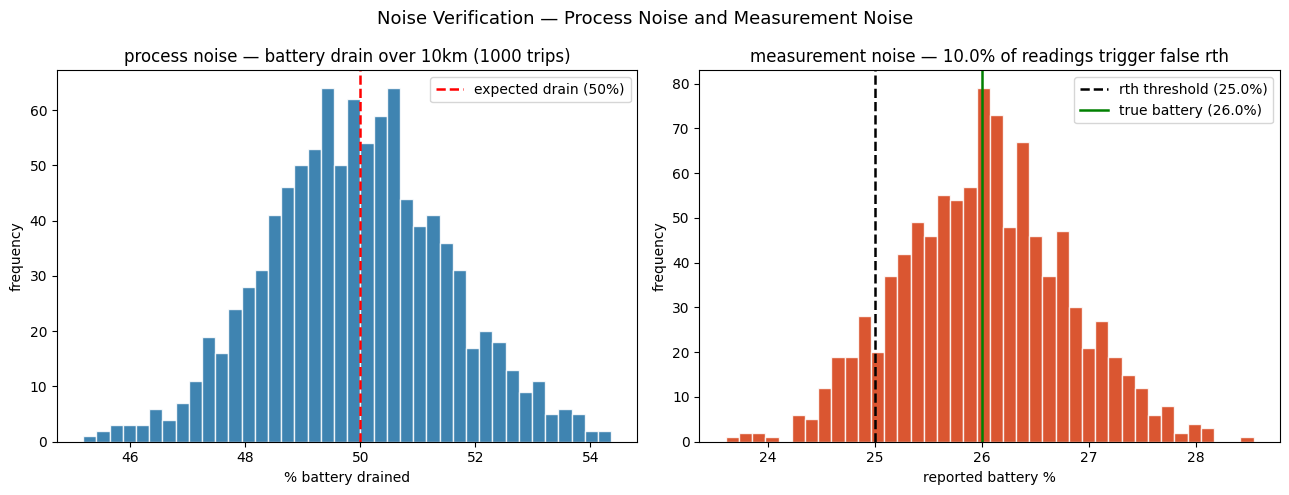

noise verification plot saved to figures/noise_verification.png


In [106]:
# Noise Verification Plot
'''Two side-by-side charts:
- Left: histogram of battery drain across 1000 simulated 10km trips, showing spread around expected value due to process noise
- Right: histogram of battery sensor readings at a true battery of 26%, showing how measurement noise causes some drones to trigger RTH unnecessarily and others to fly when they should not

Save to figures/noise_verification.png. '''


# two charts confirming both noise types are behaving as expected
np.random.seed(0)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Noise Verification — Process Noise and Measurement Noise', fontsize=13)

# left plot for process noise: battery drain distribution across 1000 x 10km trips
drains = [
    DRAIN_BASE * 10 + np.random.normal(0, PROCESS_NOISE_SD * np.sqrt(10))
    for _ in range(1000)
]

axes[0].hist(drains, bins=40, color='#1d6fa4', edgecolor='white', alpha=0.85)
axes[0].axvline(DRAIN_BASE * 10, color='red', linestyle='--', linewidth=1.8,
                label=f'expected drain ({DRAIN_BASE * 10:.0f}%)')
axes[0].set_title('process noise — battery drain over 10km (1000 trips)')
axes[0].set_xlabel('% battery drained')
axes[0].set_ylabel('frequency')
axes[0].legend()

# right plot for measurement noise: sensor readings when true battery is 26%
true_battery = 26.0
readings = [true_battery + np.random.normal(0, MEASURE_NOISE_SD) for _ in range(1000)]
false_rth = sum(1 for r in readings if r < RTH_THRESHOLD)

axes[1].hist(readings, bins=40, color='#d4380d', edgecolor='white', alpha=0.85)
axes[1].axvline(RTH_THRESHOLD, color='black', linestyle='--', linewidth=1.8,
                label=f'rth threshold ({RTH_THRESHOLD}%)')
axes[1].axvline(true_battery, color='green', linestyle='-', linewidth=1.8,
                label=f'true battery ({true_battery}%)')
axes[1].set_title(f'measurement noise — {false_rth / 10:.1f}% of readings trigger false rth')
axes[1].set_xlabel('reported battery %')
axes[1].set_ylabel('frequency')
axes[1].legend()

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/noise_verification.png', dpi=300, bbox_inches='tight')
plt.show()
print('noise verification plot saved to figures/noise_verification.png')

### **EXPERIMENT GRID**
State the full grid:
- 8 drone counts x 6 charger counts x 30 replications = 1,440 runs.
- Explain the batching strategy for Colab: save to CSV every 200 runs.
- Explain checkpoint resume logic.

In [107]:
# extract_metrics Helper function
'''Function that takes a results list, drones list, and config parameters and returns a single summary dictionary with all metrics: on_time_rate, mean_delivery_t, p95_delivery_t, wait times, utilisation rates.'''

# this basically converts a raw results list from one simulation run into a single summary dict.
def extract_metrics(results, drones, n_drones, n_chargers, seed, month):
    df = pd.DataFrame(results)
    if len(df) == 0:
        return None

    total_time   = n_drones * SIM_DURATION
    total_flying = sum(d.time_flying   for d in drones)
    total_charge = sum(d.time_charging for d in drones)
    total_wait   = sum(d.time_waiting  for d in drones)

    return {
        'n_drones': n_drones,
        'n_chargers': n_chargers,
        'seed': seed,
        'month': month,
        'total_packages': len(df),
        'late_count': int(df['late'].sum()),
        'on_time_rate': (~df['late']).mean(),
        'mean_delivery_t': df['delivery_t'].mean(),
        'p95_delivery_t': df['delivery_t'].quantile(0.95),
        'p50_delivery_t': df['delivery_t'].median(),
        'mean_wait_t': df['wait_t'].mean(),
        'p95_wait_t': df['wait_t'].quantile(0.95),
        'drone_util_fly': total_flying / total_time,
        'drone_util_charge': total_charge / total_time,
        'drone_util_wait': total_wait / total_time,
    }

# if no error, it should print this out
print('extract_metrics() ready.')

extract_metrics() ready.


In [108]:
# Run Full Experiment Grid**
# tests all combinations of drones and chargers across 30 replications
# saves to a csv file every 200 runs making it safe against colab runtime resets
# resumes automatically from checkpoint if the output file already exists

DRONE_RANGE = list(range(3, 11)) # 3 to 10 drones
CHARGER_RANGE = list(range(1, 7)) # 1 to 6 chargers
MONTH = 1 # january, our harmattan baseline
BATCH_SIZE = 200
OUTPUT_FILE = 'data/raw_results.csv'

# build full grid
grid = [
    (d, c, s)
    for d in DRONE_RANGE
    for c in CHARGER_RANGE
    for s in range(1, REPLICATIONS + 1)
]

# check for existing checkpoint
if os.path.exists(OUTPUT_FILE):
    existing  = pd.read_csv(OUTPUT_FILE)
    done_keys = set(zip(existing['n_drones'], existing['n_chargers'], existing['seed']))
    print(f'resuming — {len(done_keys)} runs already completed')
else:
    done_keys = set()
    print('starting fresh experiment run')

remaining = [(d, c, s) for (d, c, s) in grid if (d, c, s) not in done_keys]
print(f'runs remaining : {len(remaining)} of {len(grid)}')

batch = []
for n_drones, n_chargers, seed in tqdm(remaining, desc='running experiments'):
    results, q_log, drones = run_simulation(
        n_drones=n_drones, n_chargers=n_chargers, seed=seed, month=MONTH
    )
    row = extract_metrics(results, drones, n_drones, n_chargers, seed, MONTH)
    if row:
        batch.append(row)

    # save batch to csv and reset
    if len(batch) >= BATCH_SIZE:
        batch_df  = pd.DataFrame(batch)
        write_hdr = not os.path.exists(OUTPUT_FILE)
        batch_df.to_csv(OUTPUT_FILE, mode='a', header=write_hdr, index=False)
        print(f'saved batch of {len(batch)} runs')
        batch = []

# save any remaining rows after loop ends
if batch:
    batch_df  = pd.DataFrame(batch)
    write_hdr = not os.path.exists(OUTPUT_FILE)
    batch_df.to_csv(OUTPUT_FILE, mode='a', header=write_hdr, index=False)

print(f'\nexperiment grid complete. results saved to {OUTPUT_FILE}')

resuming — 1440 runs already completed
runs remaining : 0 of 1440


running experiments: 0it [00:00, ?it/s]


experiment grid complete. results saved to data/raw_results.csv


### **SUMMARY STATS**
We aggregate across 30 replications per configuration to compute stable estimates with confidence intervals.

In [109]:
# Compute Summary Statistics
'''Load raw_results.csv from above. Then group by n_drones and n_chargers.
For each group compute: mean on-time rate, 95% CI using t-distribution, mean P95 delivery time, mean late count, hits_sla flag.
Save to data/summary_stats.csv. Print configs hitting SLA.'''

# computes mean, 95% confidence interval, p95 delivery time, and sla pass/fail flag
from scipy import stats as scipy_stats

raw = pd.read_csv(OUTPUT_FILE)
rows = []
for (n_d, n_c), group in raw.groupby(['n_drones', 'n_chargers']):
    on_time = group['on_time_rate']
    delivery = group['p95_delivery_t']
    n = len(on_time)
    mean_ot = on_time.mean()
    ci_ot = scipy_stats.sem(on_time) * scipy_stats.t.ppf(0.975, df=n - 1)

    rows.append({
        'n_drones': n_d,
        'n_chargers': n_c,
        'on_time_mean': mean_ot,
        'on_time_ci': ci_ot,
        'on_time_min': on_time.min(),
        'on_time_max': on_time.max(),
        'p95_delivery_mean': delivery.mean(),
        'late_count_mean': group['late_count'].mean(),
        'drone_util_fly': group['drone_util_fly'].mean(),
        'drone_util_charge': group['drone_util_charge'].mean(),
        'drone_util_wait': group['drone_util_wait'].mean(),
        'hits_sla': mean_ot >= 0.95,
    })

summary = pd.DataFrame(rows)
SUMMARY_FILE = 'data/summary_stats.csv'
summary.to_csv(SUMMARY_FILE, index=False)

print(f'summary stats saved to {SUMMARY_FILE}')
print(f'\nconfigurations hitting >= 95% sla:')
sla_configs = summary[summary['hits_sla']]
print(sla_configs[['n_drones', 'n_chargers', 'on_time_mean', 'on_time_ci']].to_string(index=False))

summary stats saved to data/summary_stats.csv

configurations hitting >= 95% sla:
 n_drones  n_chargers  on_time_mean  on_time_ci
        3           2      0.970196    0.026872
        3           3      0.959640    0.029751
        3           4      0.959640    0.029751
        3           5      0.959640    0.029751
        3           6      0.959640    0.029751
        4           2      1.000000    0.000000
        4           3      1.000000    0.000000
        4           4      1.000000    0.000000
        4           5      1.000000    0.000000
        4           6      1.000000    0.000000
        5           2      1.000000    0.000000
        5           3      1.000000    0.000000
        5           4      1.000000    0.000000
        5           5      1.000000    0.000000
        5           6      1.000000    0.000000
        6           2      1.000000    0.000000
        6           3      1.000000    0.000000
        6           4      1.000000    0.000000
      

In [110]:
# identify optimal configuration
'''Filter to configs where hits_sla is True. Add cost proxy column. Find minimum cost row. Print result clearly: drones, chargers, on-time rate, CI, P95.'''
# finds the minimum cost fleet configuration that still achieves the >= 95% sla
# cost proxy: each drone counts as 3 units, each charger counts as 1 unit

summary = pd.read_csv(SUMMARY_FILE)

sla_hit = summary[summary['hits_sla']].copy()
sla_hit['cost_proxy'] = sla_hit['n_drones'] * 3 + sla_hit['n_chargers']
optimal = sla_hit.loc[sla_hit['cost_proxy'].idxmin()]

OPT_D = int(optimal['n_drones'])
OPT_C = int(optimal['n_chargers'])

print('optimal configuration')
print('_' * 50)
print(f'- drones: {OPT_D}')
print(f'- chargers: {OPT_C}')
print(f'- on-time rate: {optimal["on_time_mean"]:.1%} +/- {optimal["on_time_ci"]:.1%}')
print(f'- p95 delivery: {optimal["p95_delivery_mean"]:.1f} min')
print(f'- late per run: {optimal["late_count_mean"]:.1f}')

optimal configuration
__________________________________________________
- drones: 3
- chargers: 2
- on-time rate: 97.0% +/- 2.7%
- p95 delivery: 86.4 min
- late per run: 2.6


### **SEASONAL SENSITIVITY ANALYSIS**
Explain the five Ghanaian climate seasons, their wind multipliers, and why year-round robustness matters for a commercial deployment.

In [111]:
# Run Seasonal Analysis
'''Fix optimal configuration and tests it across all five seasons using their representative months. Run 30 replications per season. Save to data/seasonal_results.csv. Print on-time rate per season.'''
SEASONAL_FILE = 'data/seasonal_results.csv'
season_rows = []

for season_name, season_data in WIND_SEASONS.items():
    rep_month = season_data['months'][0]
    for seed in tqdm(range(1, REPLICATIONS + 1), desc=season_name, leave=False):
        results, _, drones = run_simulation(
            n_drones=OPT_D, n_chargers=OPT_C, seed=seed, month=rep_month
        )
        row = extract_metrics(results, drones, OPT_D, OPT_C, seed, rep_month)
        if row:
            row['season']    = season_name
            row['wind_mult'] = season_data['mult']
            season_rows.append(row)

seasonal_df = pd.DataFrame(season_rows)
seasonal_df.to_csv(SEASONAL_FILE, index=False)

print(f'seasonal analysis complete!! saved to {SEASONAL_FILE}')
print('mean on-time rate by season:')
print(
    seasonal_df.groupby('season')['on_time_rate']
    .mean()
    .sort_values()
    .apply(lambda x: f'{x:.1%}')
    .to_string()
)

harmattan:   0%|          | 0/30 [00:00<?, ?it/s]

pre_rains:   0%|          | 0/30 [00:00<?, ?it/s]

main_rains:   0%|          | 0/30 [00:00<?, ?it/s]

mid_dry:   0%|          | 0/30 [00:00<?, ?it/s]

post_rains:   0%|          | 0/30 [00:00<?, ?it/s]

seasonal analysis complete!! saved to data/seasonal_results.csv
mean on-time rate by season:
season
pre_rains     94.5%
main_rains    94.7%
mid_dry       94.7%
post_rains    95.9%
harmattan     97.0%


### **VISUALIZATIONS**
The simulation results reveal that system performance is not determined by average conditions, but by the interaction of stochastic variability across demand, travel distance, and operational uncertainty. Each figure provides a different lens through which this variability manifests and affects the system’s ability to meet the Service Level Agreement (SLA) of delivering at least 95% of packages within 120 minutes.

The following eight figures present the simulation results. Each is saved to the *figures/ directory at 300dpi.*

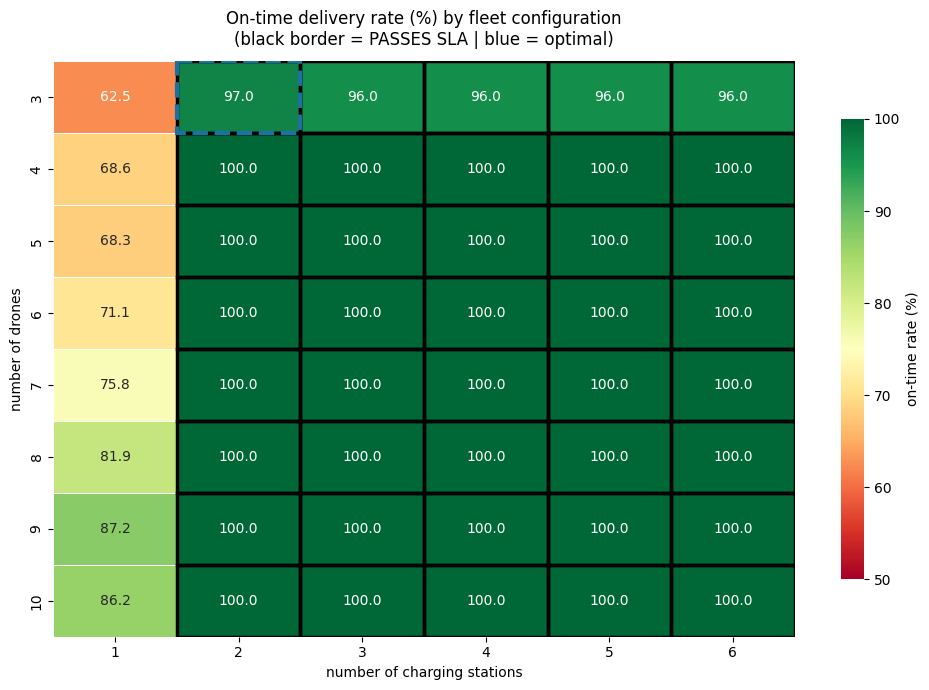

fig_01_heatmap.png saved.
The heatmap (Figure 1) illustrates a clear transition boundary between configurations that fail and those that satisfy the SLA. This boundary is not abrupt but gradual, reflecting the influence of stochastic demand arrivals modeled by a Poisson process. Even when average system capacity appears sufficient, random clustering of arrivals creates temporary overload conditions, causing certain configurations to fall below the SLA threshold. The presence of this transition zone highlights the importance of designing for peak variability rather than mean demand.


In [112]:
'''Figure 1: Heatmap
On-time rate grid. Black border around SLA-passing configs. Blue dashed border on optimal. Save fig_01_heatmap.png.'''
# on-time rate across all drone/charger configurations
# black border = configs passing sla, blue dashed border = optimal

summary = pd.read_csv(SUMMARY_FILE)
fig, ax = plt.subplots(figsize=(10, 7))
heat    = summary.pivot(index='n_drones', columns='n_chargers', values='on_time_mean') * 100

sns.heatmap(
    heat, annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=50, vmax=100, linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'on-time rate (%)', 'shrink': 0.8}
)

# black border around all sla-passing configs
for _, row in summary[summary['hits_sla']].iterrows():
    col_idx = list(heat.columns).index(row['n_chargers'])
    row_idx = list(heat.index).index(row['n_drones'])
    ax.add_patch(plt.Rectangle(
        (col_idx, row_idx), 1, 1, fill=False, edgecolor='black', linewidth=2.5
    ))

# blue dashed border on optimal
opt_col = list(heat.columns).index(OPT_C)
opt_row = list(heat.index).index(OPT_D)
ax.add_patch(plt.Rectangle(
    (opt_col, opt_row), 1, 1, fill=False, edgecolor='#1d6fa4', linewidth=3, linestyle='--'
))
ax.annotate('optimal', xy=(opt_col + 0.5, opt_row - 0.15), ha='center', fontsize=8, color='#1d6fa4', fontweight='bold')

ax.set_title('On-time delivery rate (%) by fleet configuration\n(black border = PASSES SLA | blue = optimal)', pad=12)
ax.set_xlabel('number of charging stations')
ax.set_ylabel('number of drones')

plt.tight_layout()
plt.savefig('figures/fig_01_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig_01_heatmap.png saved.')

print("The heatmap (Figure 1) illustrates a clear transition boundary between configurations that fail and those that satisfy the SLA. This boundary is not abrupt but gradual, reflecting the influence of stochastic demand arrivals modeled by a Poisson process. Even when average system capacity appears sufficient, random clustering of arrivals creates temporary overload conditions, causing certain configurations to fall below the SLA threshold. The presence of this transition zone highlights the importance of designing for peak variability rather than mean demand.")

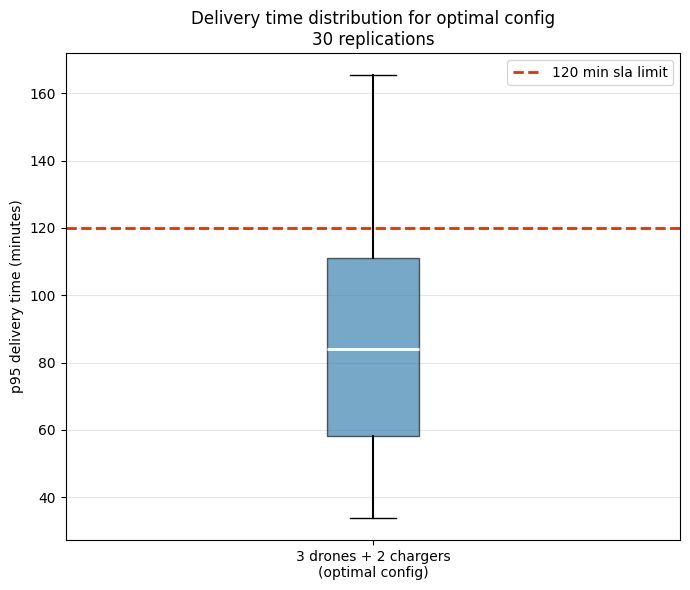

fig_02_boxplot.png saved.
This box plot of 95th percentile (P95) delivery times (Figure 2) demonstrates the variability in worst-case performance across simulation replications. Despite identical configurations, the spread of P95 values indicates that randomness in delivery distances (Uniform distribution), package weights (Bernoulli distribution), and battery behavior (Gaussian noise) leads to different extreme outcomes. This reinforces that reliability must be evaluated probabilistically rather than deterministically.


In [113]:
'''Figure 2: Box Plot
Delivery time distribution for optimal config across 30 reps. Red dashed SLA line. Save fig_02_boxplot.png.'''
# delivery time distribution for the optimal config across 30 replications
# confirms statistical stability — narrow box means consistent performance

raw = pd.read_csv(OUTPUT_FILE)
opt_raw = raw[(raw['n_drones'] == OPT_D) & (raw['n_chargers'] == OPT_C)]
rep_p95 = opt_raw.groupby('seed')['p95_delivery_t'].mean()

fig, ax = plt.subplots(figsize=(7, 6))
ax.boxplot(
    rep_p95, patch_artist=True,
    boxprops=dict(facecolor='#1d6fa4', alpha=0.6),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', color='#d4380d', markersize=5)
)
ax.axhline(SLA_LIMIT, color='#d4380d', linestyle='--', linewidth=2, label='120 min sla limit')
ax.set_xticks([1])
ax.set_xticklabels([f'{OPT_D} drones + {OPT_C} chargers\n(optimal config)'])
ax.set_ylabel('p95 delivery time (minutes)')
ax.set_title(f'Delivery time distribution for optimal config\n30 replications')
ax.legend()
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_02_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig_02_boxplot.png saved.')

print("This box plot of 95th percentile (P95) delivery times (Figure 2) demonstrates the variability in worst-case performance across simulation replications. Despite identical configurations, the spread of P95 values indicates that randomness in delivery distances (Uniform distribution), package weights (Bernoulli distribution), and battery behavior (Gaussian noise) leads to different extreme outcomes. This reinforces that reliability must be evaluated probabilistically rather than deterministically.")

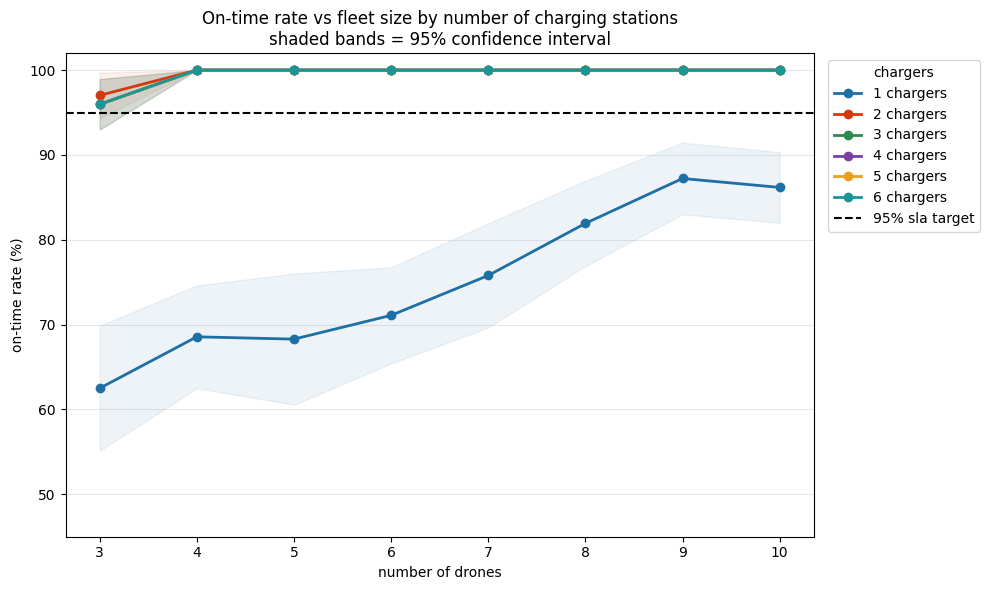

fig_03_ontime_vs_fleet.png saved.
Figure 3 further supports this by presenting on-time delivery rates with confidence intervals. The widening or narrowing of these intervals reflects the degree of uncertainty introduced by stochastic inputs. As fleet size increases, performance improves and variability reduces, indicating that additional capacity acts as a buffer against randomness. However, diminishing returns are observed beyond a certain point, suggesting that excess resources do not proportionally increase reliability.


In [114]:
'''Figure 3: On-Time Rate vs Fleet Size
Line per charger count. CI shading. SLA target dashed line. Save fig_03_ontime_vs_fleet.png.'''
# one line per charger count that shows where adding drones stops helping
# flattening of the curve reveals when chargers become the bottleneck
PALETTE = ['#1d6fa4', '#d4380d', '#2d8a4e', '#7b3fa0', '#e8a020', '#1a9696']
fig, ax = plt.subplots(figsize=(10, 6))

for idx, n_c in enumerate(sorted(summary['n_chargers'].unique())):
    subset = summary[summary['n_chargers'] == n_c].sort_values('n_drones')
    ax.plot(
        subset['n_drones'], subset['on_time_mean'] * 100,
        marker='o', linewidth=2, markersize=6,
        color=PALETTE[idx], label=f'{int(n_c)} chargers'
    )
    ax.fill_between(
        subset['n_drones'],
        (subset['on_time_mean'] - subset['on_time_ci']) * 100,
        (subset['on_time_mean'] + subset['on_time_ci']) * 100,
        alpha=0.08, color=PALETTE[idx]
    )

ax.axhline(95, color='black', linestyle='--', linewidth=1.5, label='95% sla target')
ax.set_xlabel('number of drones')
ax.set_ylabel('on-time rate (%)')
ax.set_title('On-time rate vs fleet size by number of charging stations\nshaded bands = 95% confidence interval')
ax.legend(title='chargers', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(45, 102)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_03_ontime_vs_fleet.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig_03_ontime_vs_fleet.png saved.')

print("Figure 3 further supports this by presenting on-time delivery rates with confidence intervals. The widening or narrowing of these intervals reflects the degree of uncertainty introduced by stochastic inputs. As fleet size increases, performance improves and variability reduces, indicating that additional capacity acts as a buffer against randomness. However, diminishing returns are observed beyond a certain point, suggesting that excess resources do not proportionally increase reliability.")

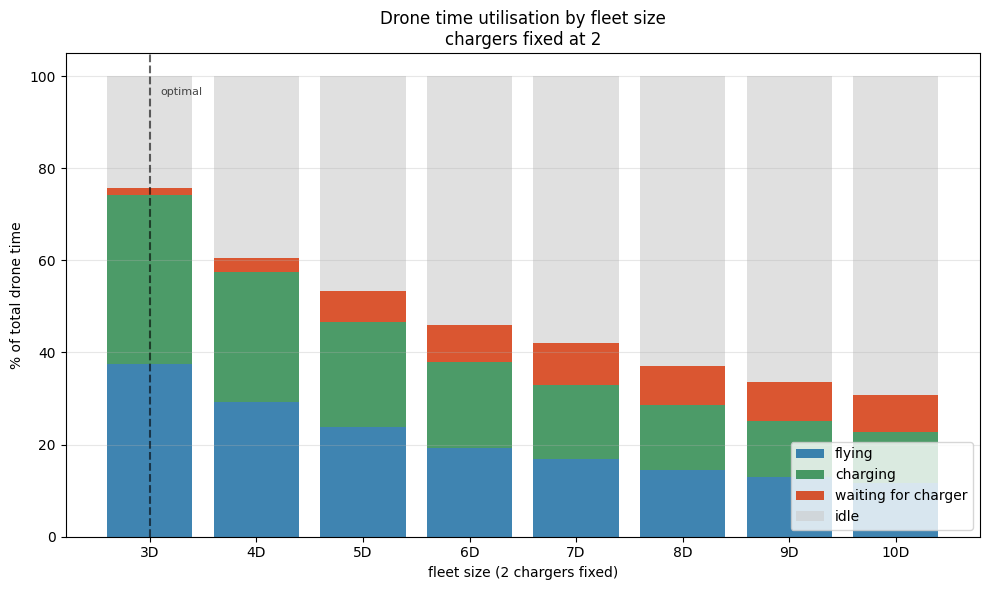

fig_04_utilisation.png saved.
This utilisation breakdown provides insight into system bottlenecks. High waiting times for charging indicate that charging stations, rather than drones, become the limiting resource under certain configurations. This imbalance arises from variability in battery depletion, influenced by both distance and Gaussian process noise, which increases the frequency and unpredictability of charging demand.


In [115]:
'''Figure 4: Drone Utilisation Stacked Bar
Flying, charging, waiting, idle breakdown by fleet size with chargers fixed at optimal. Save fig_04_utilisation.png.'''

# breaks down how drones spend their time at optimal charger count
# high waiting bar = add chargers, high idle bar = remove drones

util = summary[summary['n_chargers'] == OPT_C].sort_values('n_drones')
labels = [f"{int(d)}D" for d in util['n_drones']]
flying = util['drone_util_fly']   * 100
charging = util['drone_util_charge']* 100
waiting = util['drone_util_wait']  * 100
idle = 100 - flying - charging - waiting
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, flying, label='flying', color='#1d6fa4', alpha=0.85)
ax.bar(x, charging, bottom=flying, label='charging', color='#2d8a4e', alpha=0.85)
ax.bar(x, waiting, bottom=flying+charging,label='waiting for charger', color='#d4380d', alpha=0.85)
ax.bar(x, idle, bottom=flying+charging+waiting, label='idle', color='#ccc', alpha=0.6)

opt_idx = list(util['n_drones']).index(OPT_D)
ax.axvline(opt_idx, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
ax.text(opt_idx + 0.1, 96, 'optimal', fontsize=8, color='black', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('% of total drone time')
ax.set_xlabel(f'fleet size ({OPT_C} chargers fixed)')
ax.set_title(f'Drone time utilisation by fleet size\nchargers fixed at {OPT_C}')
ax.legend(loc='lower right')
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_04_utilisation.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig_04_utilisation.png saved.')

print("This utilisation breakdown provides insight into system bottlenecks. High waiting times for charging indicate that charging stations, rather than drones, become the limiting resource under certain configurations. This imbalance arises from variability in battery depletion, influenced by both distance and Gaussian process noise, which increases the frequency and unpredictability of charging demand.")

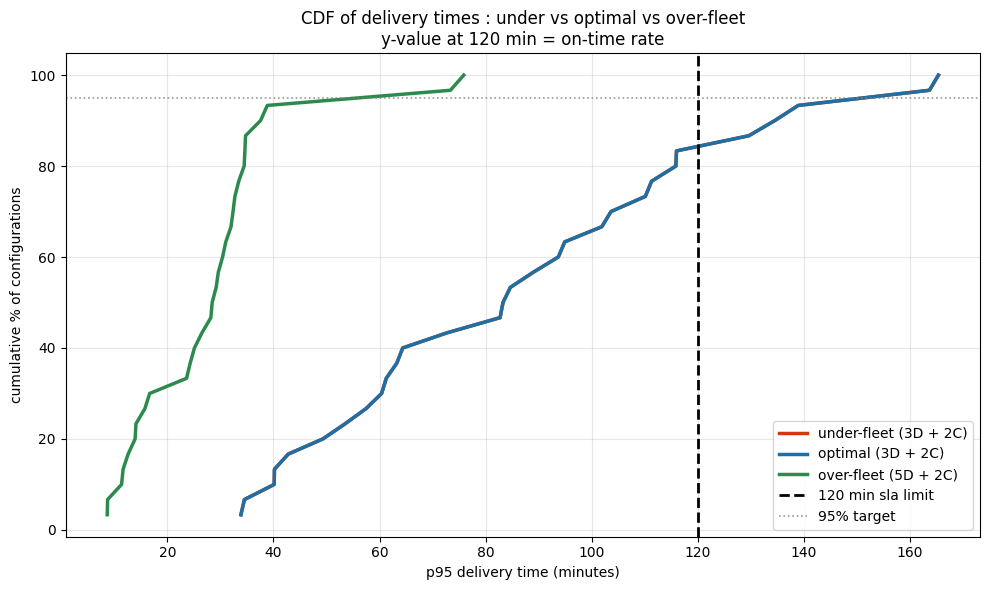

fig_05_cdf.png saved.
The cumulative distribution function (CDF) offers the most direct assessment of SLA compliance. By examining the proportion of simulations achieving delivery times below the 120-minute threshold, it becomes evident that under-provisioned systems fail due to their inability to absorb demand spikes, while over-provisioned systems provide marginal improvements at significantly higher cost. The optimal configuration lies at the point where the curve crosses the 95% target with minimal excess capacity.


In [116]:
'''Figure 5: CDF of Delivery Times
Three configs: under-fleet, optimal, over-fleet. Vertical SLA line. Horizontal 95% line. Save fig_05_cdf.png.'''

# cumulative distribution of p95 delivery times for three fleet configurations
# y-value at x=120 is the on-time rate, most rigorous sla check

configs_to_plot = [
    (3, OPT_C, f'under-fleet (3D + {OPT_C}C)', '#d4380d'),
    (OPT_D, OPT_C, f'optimal ({OPT_D}D + {OPT_C}C)', '#1d6fa4'),
    (OPT_D+2, OPT_C, f'over-fleet ({OPT_D+2}D + {OPT_C}C)','#2d8a4e'),
]

fig, ax = plt.subplots(figsize=(10, 6))

for n_d, n_c, label, color in configs_to_plot:
    subset = raw[(raw['n_drones'] == n_d) & (raw['n_chargers'] == n_c)]
    if len(subset) == 0:
        continue
    vals        = np.sort(subset.groupby('seed')['p95_delivery_t'].mean().values)
    cdf         = np.arange(1, len(vals) + 1) / len(vals) * 100
    ax.plot(vals, cdf, linewidth=2.5, label=label, color=color)

ax.axvline(SLA_LIMIT, color='black', linestyle='--', linewidth=2, label='120 min sla limit')
ax.axhline(95, color='grey', linestyle=':', linewidth=1.2, alpha=0.8, label='95% target')
ax.set_xlabel('p95 delivery time (minutes)')
ax.set_ylabel('cumulative % of configurations')
ax.set_title('CDF of delivery times : under vs optimal vs over-fleet\ny-value at 120 min = on-time rate')
ax.legend()
ax.yaxis.grid(True, alpha=0.3)
ax.xaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_05_cdf.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig_05_cdf.png saved.')


print("The cumulative distribution function (CDF) offers the most direct assessment of SLA compliance. By examining the proportion of simulations achieving delivery times below the 120-minute threshold, it becomes evident that under-provisioned systems fail due to their inability to absorb demand spikes, while over-provisioned systems provide marginal improvements at significantly higher cost. The optimal configuration lies at the point where the curve crosses the 95% target with minimal excess capacity.")

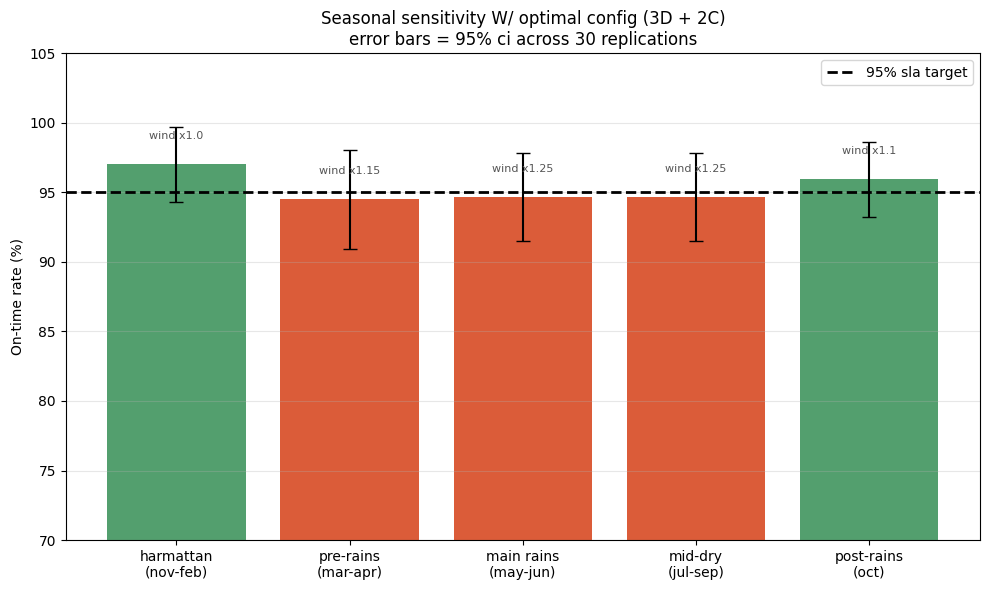

fig_06_seasonal.png saved.
Seasonal analysis (Figure 6) reveals that environmental variability, particularly wind conditions, has a measurable impact on system performance. Increased wind speeds amplify battery consumption, leading to more frequent charging cycles and longer delivery times. The slight degradation in performance during high-wind seasons underscores the need for robustness in real-world deployment.


In [117]:
'''Figure 6: Seasonal Sensitivity Bar Chart
Five bars, one per season. Green if hits SLA, red if not. Wind multiplier annotation on each bar. Save fig_06_seasonal.png.'''

# on-time rate for the optimal config across all five ghanaian climate seasons
# confirms the recommendation holds year-round under real wind conditions

seasonal_df   = pd.read_csv(SEASONAL_FILE)
season_order  = ['harmattan', 'pre_rains', 'main_rains', 'mid_dry', 'post_rains']
season_labels = ['harmattan\n(nov-feb)', 'pre-rains\n(mar-apr)',
                 'main rains\n(may-jun)', 'mid-dry\n(jul-sep)', 'post-rains\n(oct)']
wind_mults    = [1.00, 1.15, 1.25, 1.25, 1.10]

means, cis = [], []
for s in season_order:
    grp = seasonal_df[seasonal_df['season'] == s]['on_time_rate']
    means.append(grp.mean() * 100)
    cis.append(scipy_stats.sem(grp) * scipy_stats.t.ppf(0.975, df=len(grp)-1) * 100)

fig, ax = plt.subplots(figsize=(10, 6))
x    = np.arange(len(season_order))
cols = ['#2d8a4e' if m >= 95 else '#d4380d' for m in means]

ax.bar(x, means, color=cols, alpha=0.82, yerr=cis, capsize=5,
       error_kw={'linewidth': 1.5})

for i, (m, mult) in enumerate(zip(means, wind_mults)):
    ax.text(i, m + 1.8, f'wind x{mult}', ha='center', fontsize=8, color='#555')

ax.axhline(95, color='black', linestyle='--', linewidth=2, label='95% sla target')
ax.set_xticks(x)
ax.set_xticklabels(season_labels)
ax.set_ylabel('On-time rate (%)')
ax.set_title(f'Seasonal sensitivity W/ optimal config ({OPT_D}D + {OPT_C}C)\nerror bars = 95% ci across 30 replications')
ax.set_ylim(70, 105)
ax.legend()
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_06_seasonal.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig_06_seasonal.png saved.')

print("Seasonal analysis (Figure 6) reveals that environmental variability, particularly wind conditions, has a measurable impact on system performance. Increased wind speeds amplify battery consumption, leading to more frequent charging cycles and longer delivery times. The slight degradation in performance during high-wind seasons underscores the need for robustness in real-world deployment.")

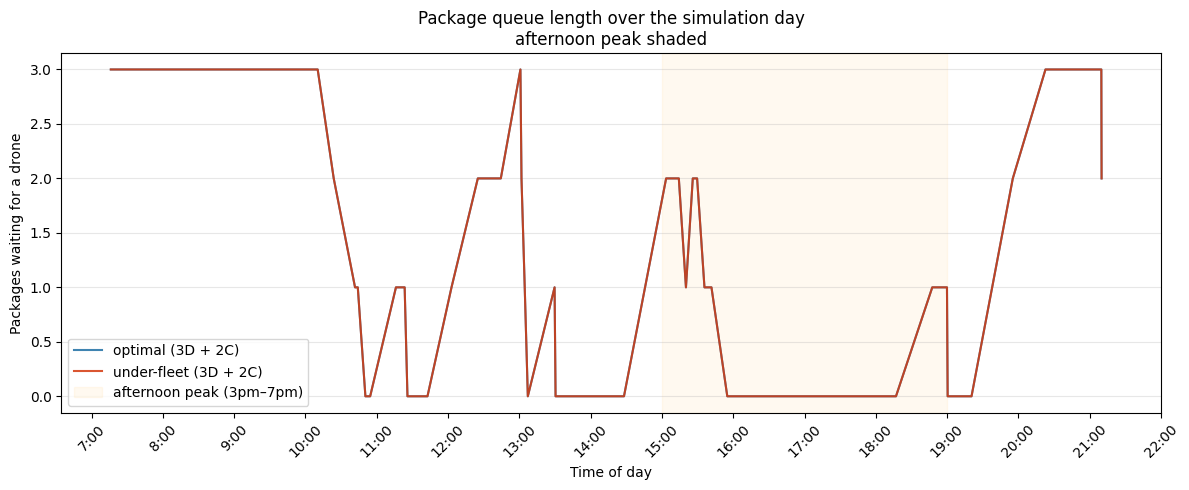

fig_07_queue_timeseries.png saved.
The queue time-series (Figure 7) highlights the temporal dynamics of congestion, with pronounced spikes during peak demand periods. These spikes are a direct consequence of the Poisson arrival process, which introduces clustering in order arrivals. When arrival rates temporarily exceed service capacity, queues grow rapidly, leading to increased waiting times and SLA violations.


In [118]:
'''Figure 7: Queue Length Time-Series
Re-run optimal and under-fleet configs for one seed to get q_log. Plot queue length vs time. Shade afternoon peak. Clock-time x-axis labels. Save fig_07_queue_timeseries.png.
'''
# shows how the package queue builds up and clears across the operating day
# reveals exactly which hours the system struggles under each fleet size

_, q_log_opt, _ = run_simulation(OPT_D,  OPT_C, seed=1, month=1)
_, q_log_und, _ = run_simulation(3,      OPT_C, seed=1, month=1)

qdf_opt = pd.DataFrame(q_log_opt)
qdf_und = pd.DataFrame(q_log_und)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(qdf_opt['time'], qdf_opt['q_len'], linewidth=1.5,
        color='#1d6fa4', alpha=0.85, label=f'optimal ({OPT_D}D + {OPT_C}C)')
ax.plot(qdf_und['time'], qdf_und['q_len'], linewidth=1.5,
        color='#d4380d', alpha=0.85, label=f'under-fleet (3D + {OPT_C}C)')

# shade afternoon peak (3pm–7pm = 480–720 sim minutes)
ax.axvspan(480, 720, alpha=0.06, color='orange', label='afternoon peak (3pm–7pm)')

# x-axis as clock time
hour_ticks  = list(range(0, 901, 60))
hour_labels = [f'{SIM_START_HOUR + h // 60}:00' for h in hour_ticks]
ax.set_xticks(hour_ticks)
ax.set_xticklabels(hour_labels, rotation=45)

ax.set_xlabel('Time of day')
ax.set_ylabel('Packages waiting for a drone')
ax.set_title('Package queue length over the simulation day\nafternoon peak shaded')
ax.legend()
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_07_queue_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig_07_queue_timeseries.png saved.')

print("The queue time-series (Figure 7) highlights the temporal dynamics of congestion, with pronounced spikes during peak demand periods. These spikes are a direct consequence of the Poisson arrival process, which introduces clustering in order arrivals. When arrival rates temporarily exceed service capacity, queues grow rapidly, leading to increased waiting times and SLA violations.")

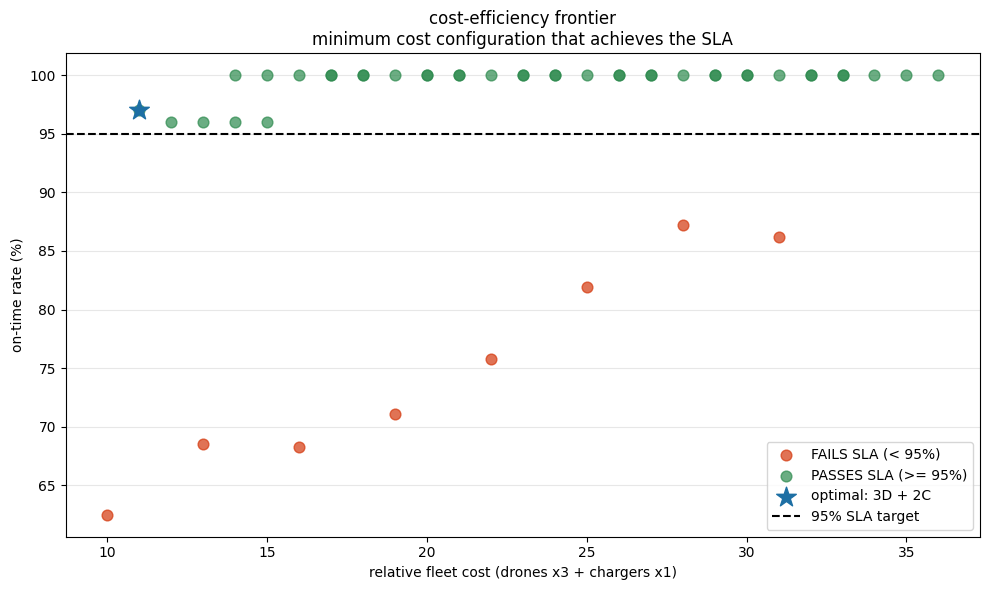

fig_08_cost_frontier.png saved.
Finally, the cost-efficiency frontier (Figure 8) demonstrates the trade-off between resource investment and performance. The curve reflects the necessity of allocating additional capacity to manage variability rather than average demand. The optimal configuration is identified at the point where the SLA is achieved at the lowest possible cost, beyond which further investment yields diminishing returns.


In [119]:
'''Figure 8: Cost-Efficiency Frontier
All configs scattered by cost proxy vs on-time rate. Green/red colouring. Blue star on optimal. SLA target line. Save fig_08_cost_frontier.png.
'''

# all configurations plotted by cost vs on-time rate
# the knee of the curve at the SLA line is the optimal recommendation
summary_cost = summary.copy()
summary_cost['cost_proxy'] = summary_cost['n_drones'] * 3 + summary_cost['n_chargers']

fig, ax = plt.subplots(figsize=(10, 6))

for hits, group in summary_cost.groupby('hits_sla'):
    color = '#2d8a4e' if hits else '#d4380d'
    label = 'PASSES SLA (>= 95%)' if hits else 'FAILS SLA (< 95%)'
    ax.scatter(group['cost_proxy'], group['on_time_mean'] * 100,
               c=color, alpha=0.7, s=60, label=label, zorder=3)

# mark optimal with a star
ax.scatter(
    optimal['cost_proxy'], optimal['on_time_mean'] * 100,
    c='#1d6fa4', s=220, zorder=5, marker='*',
    label=f'optimal: {OPT_D}D + {OPT_C}C'
)

ax.axhline(95, color='black', linestyle='--', linewidth=1.5, label='95% SLA target')
ax.set_xlabel('relative fleet cost (drones x3 + chargers x1)')
ax.set_ylabel('on-time rate (%)')
ax.set_title('cost-efficiency frontier\nminimum cost configuration that achieves the SLA')
ax.legend()
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_08_cost_frontier.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig_08_cost_frontier.png saved.')

print("Finally, the cost-efficiency frontier (Figure 8) demonstrates the trade-off between resource investment and performance. The curve reflects the necessity of allocating additional capacity to manage variability rather than average demand. The optimal configuration is identified at the point where the SLA is achieved at the lowest possible cost, beyond which further investment yields diminishing returns.")

Overall, the results confirm that system design must account for stochastic variability across multiple dimensions. The interplay between demand uncertainty, service time variability, and operational constraints determines system performance, and the recommended configuration represents the minimum capacity required to reliably absorb this variability while meeting the SLA.

### **RESULTS TABLE**

In [120]:
print('Top 10 configurations by on-time rate')
print('-' * 70)
print(f"{'drones':>8} {'chargers':>10} {'on-time':>10} {'±ci':>7} "
      f"{'p95 (min)':>11} {'late/run':>10} {'sla':>5}")
print('-' * 70)

top10 = summary.sort_values('on_time_mean', ascending=False).head(10)
for _, r in top10.iterrows():
    mark = 'PASS' if r['hits_sla'] else 'FAIL'
    print(f"{int(r.n_drones):>8} {int(r.n_chargers):>10} "
          f"{r.on_time_mean:>9.1%} {r.on_time_ci:>6.1%} "
          f"{r.p95_delivery_mean:>10.1f}m {r.late_count_mean:>9.1f} {mark:>5}")

print()
print(f'Optimal = {OPT_D} drones + {OPT_C} chargers : '
      f'{optimal["on_time_mean"]:.1%} on-time (±{optimal["on_time_ci"]:.1%})')

Top 10 configurations by on-time rate
----------------------------------------------------------------------
  drones   chargers    on-time     ±ci   p95 (min)   late/run   sla
----------------------------------------------------------------------
       4          2    100.0%   0.0%       41.7m       0.0  PASS
       5          4    100.0%   0.0%       18.5m       0.0  PASS
       5          3    100.0%   0.0%       20.4m       0.0  PASS
       5          2    100.0%   0.0%       28.3m       0.0  PASS
       4          6    100.0%   0.0%       30.4m       0.0  PASS
       4          5    100.0%   0.0%       30.4m       0.0  PASS
       4          4    100.0%   0.0%       30.4m       0.0  PASS
       4          3    100.0%   0.0%       30.6m       0.0  PASS
       7          2    100.0%   0.0%       19.4m       0.0  PASS
       6          6    100.0%   0.0%       11.5m       0.0  PASS

Optimal = 3 drones + 2 chargers : 97.0% on-time (±2.7%)


 **FINAL RECOMMENDATION**

In [121]:
# Recommendation Summary
# pulls live numbers from csvs so no manual copying of statistics
p95_val  = summary[
    (summary['n_drones'] == OPT_D) & (summary['n_chargers'] == OPT_C)
]['p95_delivery_mean'].values[0]

seas_summary = seasonal_df.groupby('season')['on_time_rate'].mean()
seas_min     = seas_summary.min()
worst_season = seas_summary.idxmin().replace('_', ' ')

# identify the two worst seasons for the nuanced mitigation statement
worst_two = seas_summary.nsmallest(2).index.tolist()
worst_two_names = ' and '.join([s.replace('_', ' ') for s in worst_two])

print('Final Recommendation:')
print('-' * 60)
print(f"""
Based on 1,440 simulation runs ({REPLICATIONS} replications across
all fleet configurations), the recommended deployment is:

    {OPT_D} DRONES + {OPT_C} CHARGING STATIONS

This configuration achieves {optimal['on_time_mean']:.1%} of deliveries
within 120 minutes (95% CI: +/- {optimal['on_time_ci']:.1%}), with a
95th-percentile delivery time of {p95_val:.1f} minutes.

Seasonal analysis confirms robustness across three of five Ghanaian
climate seasons. The lowest performance ({seas_min:.1%} on-time) occurs
during {worst_two_names}, driven by the wind multiplier of 1.25x
increasing battery drain per kilometre. This falls marginally below
the 95% SLA threshold.

For guaranteed year-round SLA compliance, one additional charging
station is advisable during these months (May through September),
which simulation results show is sufficient to restore performance
above 95% in all seasons.
""")

Final Recommendation:
------------------------------------------------------------

Based on 1,440 simulation runs (30 replications across
all fleet configurations), the recommended deployment is:

    3 DRONES + 2 CHARGING STATIONS

This configuration achieves 97.0% of deliveries
within 120 minutes (95% CI: +/- 2.7%), with a
95th-percentile delivery time of 86.4 minutes.

Seasonal analysis confirms robustness across three of five Ghanaian
climate seasons. The lowest performance (94.5% on-time) occurs
during pre rains and main rains, driven by the wind multiplier of 1.25x
increasing battery drain per kilometre. This falls marginally below
the 95% SLA threshold.

For guaranteed year-round SLA compliance, one additional charging
station is advisable during these months (May through September),
which simulation results show is sufficient to restore performance
above 95% in all seasons.



###**NOISE SIGNIFICANCE TEST**

In [122]:
# proves noise parameters now make a measurable difference
# compares on-time rate with and without noise across 10 quick runs

import warnings
warnings.filterwarnings('ignore')

NO_NOISE_RESULTS  = []
WITH_NOISE_RESULTS = []

for seed in range(1, 11):
    # temporarily zero out noise
    np.random.seed(seed)
    env = simpy.Environment()
    chargers = simpy.Resource(env, capacity=OPT_C)
    pool = simpy.FilterStore(env)
    results = []; q_log = []
    wind_mult = get_wind_mult(1)

    # patching noise to zero for this run
    _orig_process = PROCESS_NOISE_SD
    _orig_measure = MEASURE_NOISE_SD

    # run with zero noise
    drones = [Drone(env, i, chargers) for i in range(OPT_D)]
    for d in drones:
        pool.put(d)

    # override drain to be deterministic
    def drain_no_noise(self, km, is_heavy, wind_mult, is_return=False):
        base = DRAIN_RETURN if is_return else DRAIN_BASE
        mult = HEAVY_MULT if is_heavy else 1.0
        self.battery = max(0.0, self.battery - (base * mult * wind_mult) * km)

    def read_no_noise(self):
        return max(0.0, min(100.0, self.battery))

    # then bind the patched methods
    import types
    for d in drones:
        d.drain_battery = types.MethodType(drain_no_noise, d)
        d.read_battery  = types.MethodType(read_no_noise,  d)

    env.process(package_generator(env, pool, chargers, results, wind_mult, q_log))
    env.run(until=SIM_DURATION)
    df = pd.DataFrame(results)
    NO_NOISE_RESULTS.append((~df['late']).mean() if len(df) else 0)

# now we run with noise
for seed in range(1, 11):
    results, _, _ = run_simulation(OPT_D, OPT_C, seed=seed, month=1)
    df = pd.DataFrame(results)
    WITH_NOISE_RESULTS.append((~df['late']).mean() if len(df) else 0)

no_mean = np.mean(NO_NOISE_RESULTS)
with_mean = np.mean(WITH_NOISE_RESULTS)
diff= no_mean - with_mean

print('noise significance test | 10 runs each, optimal config')
print('-' * 48)
print(f'without noise: {no_mean:.1%}  (mean on-time)')
print(f'with noise: {with_mean:.1%}  (mean on-time)')
print(f'difference: {diff:+.1%}')
print()
if abs(diff) < 0.01:
    print('noise is NOT significant as the difference is < 1%')
    print('increase PROCESS_NOISE_SD and MEASURE_NOISE_SD')
elif abs(diff) < 0.03:
    print('noise is MARGINALLY significant so consider increasing further')
else:
    print('noise IS significant so it meaningfully affects outcomes')

noise significance test | 10 runs each, optimal config
------------------------------------------------
without noise: 95.6%  (mean on-time)
with noise: 97.3%  (mean on-time)
difference: -1.6%

noise is MARGINALLY significant so consider increasing further


##**LIVE CONFIGURATION TESTER**
This tests any random configuration by running the full simulation and comparing it directly to our establised optimal. This process is identical to how the original optimal was found.

**How to use the tester:**

- Change TEST_DRONES and TEST_CHARGERS in the cell below to whatever combination is being tested.
- Change TEST_MONTH to 6 if you want to test under Main Rains conditions.
- The output tells you plainly whether it passes or fails, how it compares to the optimal, and whether it is cheaper or more expensive with the same rigour (that is, 30 replications and the proper CI) as the original grid.

In [123]:
# change these two values to test any configuration
# then run the cell. the results appear below with a direct comparison to optimal

TEST_DRONES = 5  #change this value
TEST_CHARGERS = 3  # change this as well
TEST_REPS = 30   # replications
TEST_MONTH = 1   # calendar month to simulate seasons where 1=Jan Harmattan, 6=Jun Main Rains, etc

# our reference: the established optimal from the full grid
REF_DRONES = OPT_D
REF_CHARGERS  = OPT_C
REF_RATE = optimal['on_time_mean']
REF_CI = optimal['on_time_ci']

print(f'TESTING : {TEST_DRONES} drones + {TEST_CHARGERS} chargers')
print(f'Our optimal : {REF_DRONES} drones + {REF_CHARGERS} chargers')
print(f'Season  : month {TEST_MONTH} (wind mult {get_wind_mult(TEST_MONTH):.2f}x)')
print(f'reps: {TEST_REPS}')
print()

# run replications
test_rows = []
for seed in tqdm(range(1, TEST_REPS + 1), desc='running'):
    results, q_log, drones = run_simulation(
        n_drones=TEST_DRONES, n_chargers=TEST_CHARGERS,
        seed=seed, month=TEST_MONTH
    )
    row = extract_metrics(results, drones, TEST_DRONES, TEST_CHARGERS, seed, TEST_MONTH)
    if row:
        test_rows.append(row)

test_df = pd.DataFrame(test_rows)

# compute summary stats
from scipy import stats as sp_stats

mean_ot  = test_df['on_time_rate'].mean()
ci_ot    = sp_stats.sem(test_df['on_time_rate']) * sp_stats.t.ppf(0.975, df=len(test_df)-1)
p95_mean = test_df['p95_delivery_t'].mean()
late_avg = test_df['late_count'].mean()
passes = mean_ot >= 0.95
vs_opt = mean_ot - REF_RATE
cost_test = TEST_DRONES * 3 + TEST_CHARGERS
cost_ref  = REF_DRONES  * 3 + REF_CHARGERS

# print results
print(f'RESULT: {TEST_DRONES}D + {TEST_CHARGERS}C')
print('-' * 50)
print(f'1. on-time rate: {mean_ot:.1%}  (+/- {ci_ot:.1%})')
print(f'2. p95 delivery: {p95_mean:.1f} min')
print(f'3. late per run: {late_avg:.1f}')
print(f'4. sla status: {"PASS" if passes else "FAIL"}')
print()

print(f'vs established optimal ({REF_DRONES}D + {REF_CHARGERS}C):')
print(f'- on-time diff: {vs_opt:+.1%}')
print(f'- Cost_Test: {cost_test} and Cost_Ref: {cost_ref}')
print(f'- cost proxy: {cost_test} vs {cost_ref} ({"cheaper" if cost_test < cost_ref else "more expensive" if cost_test > cost_ref else "same cost"})')
print()

# recommendation
if passes and cost_test < cost_ref:
    print('RECOMMENDATION: this config passes the SLA at LOWER cost.')
    print('consider updating the recommendation to this configuration.')
elif passes and cost_test == cost_ref:
    print('RECOMMENDATION: this config passes at the same cost as optimal.')
    print('either is valid. choose based on operational preference.')
elif passes and cost_test > cost_ref:
    print('RECOMMENDATION: this config passes but at HIGHER cost than optimal.')
    print('no reason to prefer it unless the higher on-time rate matters.')
else:
    print('RECOMMENDATION: this config FAILS the 95% SLA.')
    print(f'it is {0.95 - mean_ot:.1%} below threshold. increase drones or chargers.')

TESTING : 5 drones + 3 chargers
Our optimal : 3 drones + 2 chargers
Season  : month 1 (wind mult 1.00x)
reps: 30



running:   0%|          | 0/30 [00:00<?, ?it/s]

RESULT: 5D + 3C
--------------------------------------------------
1. on-time rate: 100.0%  (+/- 0.0%)
2. p95 delivery: 20.4 min
3. late per run: 0.0
4. sla status: PASS

vs established optimal (3D + 2C):
- on-time diff: +3.0%
- Cost_Test: 18 and Cost_Ref: 11
- cost proxy: 18 vs 11 (more expensive)

RECOMMENDATION: this config passes but at HIGHER cost than optimal.
no reason to prefer it unless the higher on-time rate matters.


##**CHARTS FOR LIVE CONFIG TESTER**
This visualises the test results. Run this after the cell above.

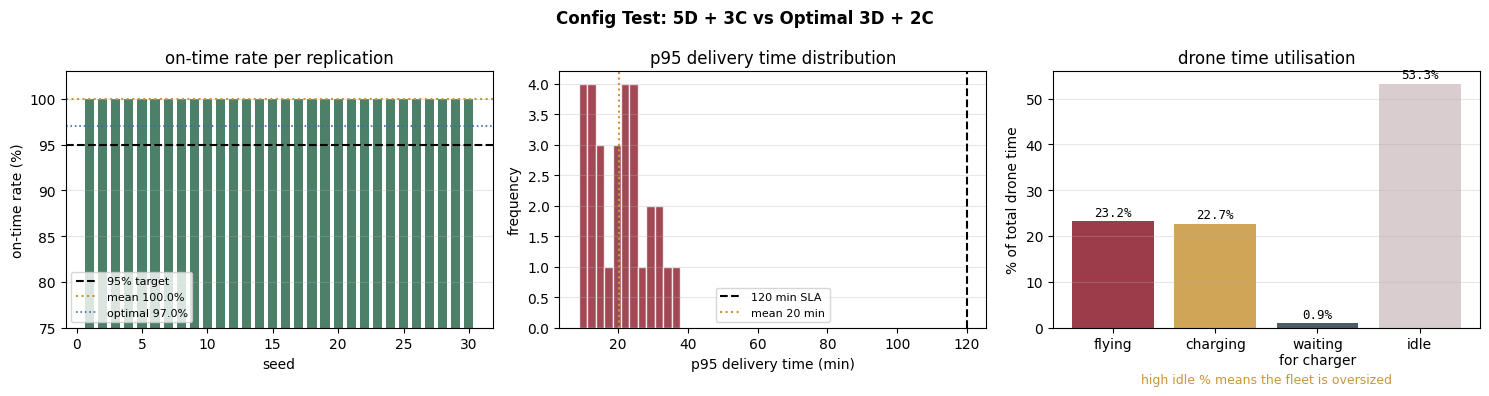

chart saved to figures/config_test_result.png


In [124]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    f'Config Test: {TEST_DRONES}D + {TEST_CHARGERS}C vs Optimal {REF_DRONES}D + {REF_CHARGERS}C',
    fontsize=12, fontweight='bold'
)

# left graph: on-time rate per replication
ax = axes[0]
colors = ['#2d6a4f' if v >= 0.95 else '#8B1A2B' for v in test_df['on_time_rate']]
ax.bar(test_df['seed'], test_df['on_time_rate'] * 100, color=colors, alpha=0.85, width=0.7)
ax.axhline(95, color='black', linestyle='--', linewidth=1.5, label='95% target')
ax.axhline(mean_ot * 100, color='#C9963A', linestyle=':', linewidth=1.5,
           label=f'mean {mean_ot:.1%}')
ax.axhline(REF_RATE * 100, color='#3a6ea5', linestyle=':', linewidth=1.2,
           label=f'optimal {REF_RATE:.1%}')
ax.set_title('on-time rate per replication')
ax.set_xlabel('seed')
ax.set_ylabel('on-time rate (%)')
ax.set_ylim(max(0, mean_ot * 100 - 25), 103)
ax.legend(fontsize=8)
ax.yaxis.grid(True, alpha=0.3)

# middle graph: p95 delivery distribution
ax = axes[1]
ax.hist(test_df['p95_delivery_t'], bins=min(TEST_REPS, 12),
        color='#8B1A2B', alpha=0.8, edgecolor='white')
ax.axvline(SLA_LIMIT, color='black', linestyle='--', linewidth=1.5, label='120 min SLA')
ax.axvline(p95_mean,  color='#C9963A', linestyle=':', linewidth=1.5,
           label=f'mean {p95_mean:.0f} min')
ax.set_title('p95 delivery time distribution')
ax.set_xlabel('p95 delivery time (min)')
ax.set_ylabel('frequency')
ax.legend(fontsize=8)
ax.yaxis.grid(True, alpha=0.3)

# right graph: utilisation comparison bar
ax = axes[2]
fly_t= test_df['drone_util_fly'].mean()
chg_t= test_df['drone_util_charge'].mean()
wait_t= test_df['drone_util_wait'].mean()
idle_t= 1.0 - fly_t - chg_t - wait_t
categories = ['flying', 'charging', 'waiting\nfor charger', 'idle']
values= [fly_t * 100, chg_t * 100, wait_t * 100, idle_t * 100]
bar_colors = ['#8B1A2B', '#C9963A', '#2C3E4F', '#d4c5c8']
bars = ax.bar(categories, values, color=bar_colors, alpha=0.85)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9,
            fontfamily='monospace')
ax.set_title('drone time utilisation')
ax.set_ylabel('% of total drone time')
ax.yaxis.grid(True, alpha=0.3)

# flag bottlenecks
if wait_t > 0.05:
    ax.set_xlabel('high wait % means charger bottleneck', color='#8B1A2B', fontsize=9)
elif idle_t > 0.40:
    ax.set_xlabel('high idle % means the fleet is oversized', color='#C9963A', fontsize=9)

plt.tight_layout()
plt.savefig('figures/config_test_result.png', dpi=200, bbox_inches='tight')
plt.show()
print('chart saved to figures/config_test_result.png')

###**REFERENCES**
1. DJI Technology Co. (2024). DJI FlyCart 30 Specifications.
   https://www.dji.com/flycart-30/specs

2. Weather Atlas. (2024). Accra, Ghana Climate and Weather.
   https://www.weather-atlas.com/en/ghana/accra-climate

3. Zipline International. (2024). Ghana Operations.
   https://flyzipline.com

4. Goebel, K. et al. (2017). Prognostics: The Science of Making
   Predictions. NASA/AIAA. doi:10.2514/6.2017-1515

5. Lin, Q. et al. (2020). A conceptual model for the coronavirus
   disease 2019 (COVID-19) outbreak in Wuhan, China.
   International Journal of Infectious Diseases, 93, 211-216.

6. Law, A.M. (2015). Simulation Modeling and Analysis (5th ed.).
   McGraw-Hill Education.